In [17]:
import pyspark
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import csv

In [13]:
from pyspark import SparkContext
from pyspark.sql import SparkSession
from pyspark.sql.types import StructField, StructType, StringType, LongType, IntegerType, FloatType
from pyspark.sql.functions import hour, to_timestamp
import pyspark.sql.functions as F
from pyspark.sql.types import *
from pyspark.ml import Pipeline
from pyspark.ml.classification import DecisionTreeClassifier
from pyspark.ml.feature import OneHotEncoder, StringIndexer, VectorAssembler, IndexToString
from pyspark.ml.evaluation import MulticlassClassificationEvaluator, BinaryClassificationEvaluator

In [3]:
ss=SparkSession.builder.master("local").appName("severity_prediction").getOrCreate()

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/12/01 22:10:06 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [4]:
data = ss.read.csv("/storage/home/mkd5951/work/Course_project/crashcrew/sampled_accident_data.csv", header=True, inferSchema=False)

In [5]:
data.printSchema()

root
 |-- ID: string (nullable = true)
 |-- Source: string (nullable = true)
 |-- Severity: string (nullable = true)
 |-- Start_Time: string (nullable = true)
 |-- End_Time: string (nullable = true)
 |-- Start_Lat: string (nullable = true)
 |-- Start_Lng: string (nullable = true)
 |-- End_Lat: string (nullable = true)
 |-- End_Lng: string (nullable = true)
 |-- Distance(mi): string (nullable = true)
 |-- Description: string (nullable = true)
 |-- Street: string (nullable = true)
 |-- City: string (nullable = true)
 |-- County: string (nullable = true)
 |-- State: string (nullable = true)
 |-- Zipcode: string (nullable = true)
 |-- Country: string (nullable = true)
 |-- Timezone: string (nullable = true)
 |-- Airport_Code: string (nullable = true)
 |-- Weather_Timestamp: string (nullable = true)
 |-- Temperature(F): string (nullable = true)
 |-- Wind_Chill(F): string (nullable = true)
 |-- Humidity(%): string (nullable = true)
 |-- Pressure(in): string (nullable = true)
 |-- Visibility(

In [7]:
data = data.dropna()

In [8]:
data.show(5)

+---------+-------+--------+-------------------+-------------------+-----------------+----------+--------+------------------+------------+--------------------+--------------------+--------+---------+-----+-------+-------+----------+------------+-------------------+--------------+-------------+-----------+------------+--------------+--------------+---------------+-----------------+-------------------+-------+-----+--------+--------+--------+-------+-------+----------+-------+-----+---------------+--------------+------------+--------------+--------------+-----------------+---------------------+
|       ID| Source|Severity|         Start_Time|           End_Time|        Start_Lat| Start_Lng| End_Lat|           End_Lng|Distance(mi)|         Description|              Street|    City|   County|State|Zipcode|Country|  Timezone|Airport_Code|  Weather_Timestamp|Temperature(F)|Wind_Chill(F)|Humidity(%)|Pressure(in)|Visibility(mi)|Wind_Direction|Wind_Speed(mph)|Precipitation(in)|  Weather_Conditi

In [39]:
cols = ["ID", "Start_Time", "Severity", "State"]
data = data.select(*cols)

In [40]:
data = data.withColumn("Hours", hour("Start_Time"))

In [41]:
data.show(5)

+---------+-------------------+--------+-----+-----+
|       ID|         Start_Time|Severity|State|Hours|
+---------+-------------------+--------+-----+-----+
|A-3447191|2016-12-06 14:28:06|       2|   OH|   14|
|A-3420085|2016-04-27 03:50:41|       2|   CA|    3|
|A-3456576|2017-01-05 16:33:16|       3|   IL|   16|
|A-3458082|2017-01-10 15:48:54|       2|   NY|   15|
|A-3459593|2017-01-16 06:48:42|       2|   IL|    6|
+---------+-------------------+--------+-----+-----+
only showing top 5 rows


In [42]:
severity_counts = (
    data.groupBy("Hours", "Severity")
      .count()
      .withColumnRenamed("count", "Accident Count")
      .orderBy("Hours", "Severity")
)

severity_counts.show()

+-----+--------+--------------+
|Hours|Severity|Accident Count|
+-----+--------+--------------+
|    0|       1|             1|
|    0|       2|           816|
|    0|       3|            14|
|    0|       4|            54|
|    1|       1|             2|
|    1|       2|           651|
|    1|       3|             5|
|    1|       4|            24|
|    2|       1|             3|
|    2|       2|           654|
|    2|       3|             4|
|    2|       4|            28|
|    3|       1|             4|
|    3|       2|           494|
|    3|       3|             6|
|    3|       4|            29|
|    4|       1|             3|
|    4|       2|           476|
|    4|       3|             8|
|    4|       4|            24|
+-----+--------+--------------+
only showing top 20 rows


In [43]:
data_with_counts = (
    data.groupBy("Hours", "Severity")
    .agg(F.count("*").alias("Accident Count"))
    .orderBy("Hours", "Severity", "Accident Count")
)

data_with_counts.show(10)

+-----+--------+--------------+
|Hours|Severity|Accident Count|
+-----+--------+--------------+
|    0|       1|             1|
|    0|       2|           816|
|    0|       3|            14|
|    0|       4|            54|
|    1|       1|             2|
|    1|       2|           651|
|    1|       3|             5|
|    1|       4|            24|
|    2|       1|             3|
|    2|       2|           654|
+-----+--------+--------------+
only showing top 10 rows


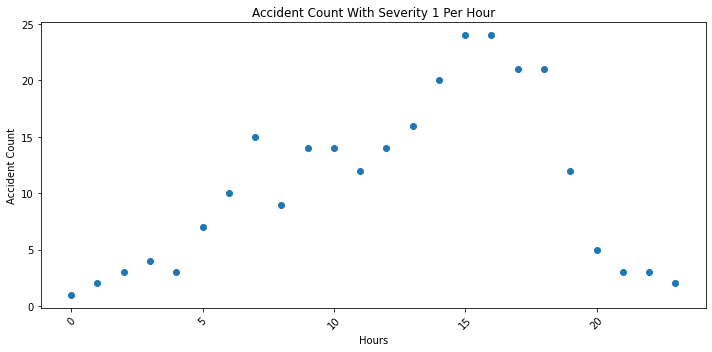

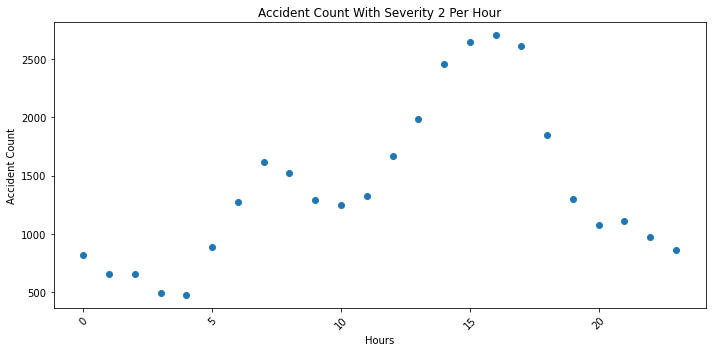

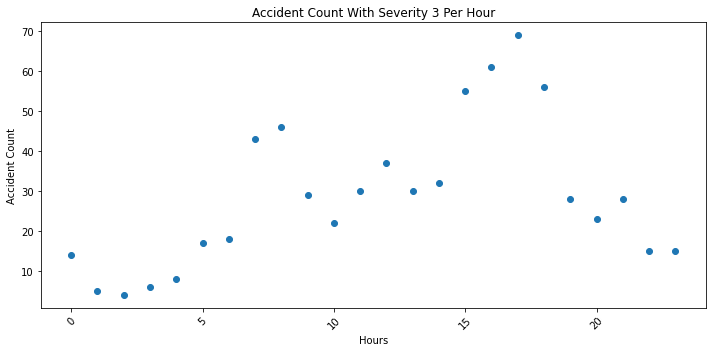

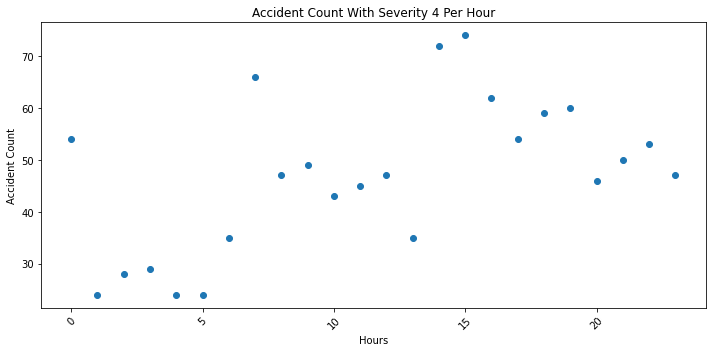

In [46]:
# Loop through severity level to output plot based on each severity
for i in range(1, 5):
    data_per_severity = data_with_counts.filter(data_with_counts["Severity"] == i).orderBy("Hours").collect()

    # Convert to numpy arrays
    times = np.array([r["Hours"] for r in data_per_severity])
    severities = np.array([r["Accident Count"] for r in data_per_severity], dtype=float)

    # Plot
    plt.figure(figsize=(10, 5))
    plt.scatter(times, severities)
    plt.title(f"Accident Count With Severity {i} Per Hour")
    plt.xlabel("Hours")
    plt.ylabel("Accident Count")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()